# 02 — EDA and Feature Selection

Exploratory data analysis and Elastic Net feature selection for a small-sample, high-dimensional dataset.
Saves preprocessing artifacts (scaler, selected features, train/test splits) via joblib.

## 2.1 Import Libraries


In [236]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import joblib

FIGURES_DIR = "figures"
DATA_DIR = "data"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Libraries loaded successfully")

Libraries loaded successfully


## 2.2 Load Data

In [237]:
molecule_df = pd.read_csv(os.path.join(DATA_DIR, "molecules.csv"))
print(f"Data shape: {molecule_df.shape}")
print(f"Columns: {len(molecule_df.columns)} (3 metadata + {len(molecule_df.columns) - 3} features)")
print(f"\nClass distribution:")
print(molecule_df.groupby(["class_label", "class_name"]).size())
print(f"\nTotal samples: {len(molecule_df)}, Features: {molecule_df.shape[1] - 3}")
molecule_df.head()

Data shape: (99, 168)
Columns: 168 (3 metadata + 165 features)

Class distribution:
class_label  class_name        
0            Capsaicinoid          33
1            Vanilloid_Gingerol    33
2            Spice_Alkaloid        33
dtype: int64

Total samples: 99, Features: 165


,compound_name,class_label,class_name,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_ketone_Topliss,fr_methoxy,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_piperdine,fr_piperzine,fr_pyridine,fr_unbrch_alkane,fr_urea
0,capsaicin,0,Capsaicinoid,11.768937,11.768937,0.055445,0.055445,0.538861,11.090909,305.418,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,0.0
1,dihydrocapsaicin,0,Capsaicinoid,11.786954,11.786954,0.079538,0.079538,0.641999,10.727273,307.434,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,3.0,0.0
2,nordihydrocapsaicin,0,Capsaicinoid,11.743056,11.743056,0.075545,0.075545,0.683597,10.666667,293.407,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,0.0
3,homocapsaicin,0,Capsaicinoid,11.810222,11.810222,0.064597,0.064597,0.502251,11.130435,319.445,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,3.0,0.0
4,homodihydrocapsaicin,0,Capsaicinoid,11.824208,11.824208,0.082613,0.082613,0.593759,10.782609,321.461,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,4.0,0.0


## 2.3 EDA — Class Distribution Bar Chart

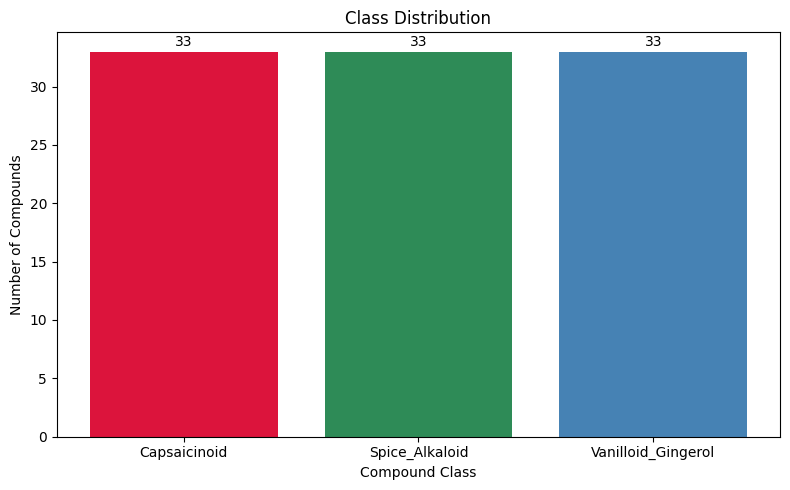

In [238]:
class_counts = molecule_df["class_name"].value_counts().sort_index()
colors = ["crimson", "seagreen", "steelblue"]

plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts.index, class_counts.values, color=colors)

plt.bar_label(bars, fmt="%d", padding=2)
plt.xlabel("Compound Class")
plt.ylabel("Number of Compounds")
plt.title("Class Distribution")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.png"), bbox_inches="tight")
plt.show()

## 2.4 EDA — Feature Correlation Heatmap (Top 20)

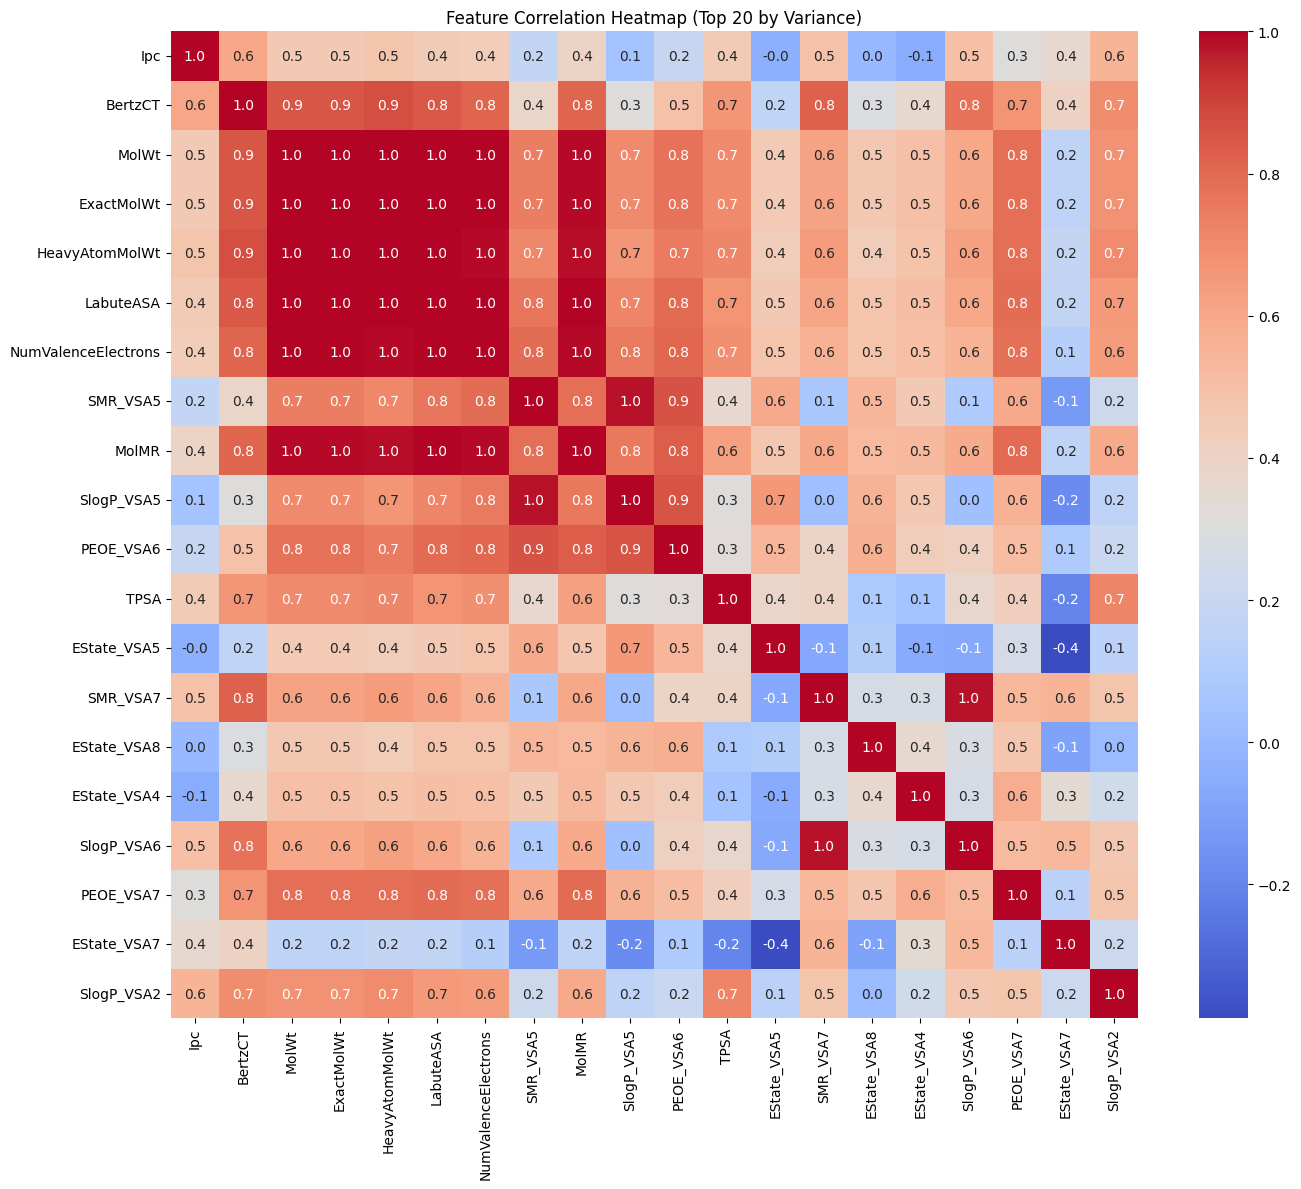

In [239]:
feature_cols = molecule_df.columns[3:]
feature_data = molecule_df[feature_cols]

top_20_features = feature_data.var().nlargest(20).index.tolist()
corr_matrix = feature_data[top_20_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap (Top 20 by Variance)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "correlation_heatmap.png"), bbox_inches="tight")
plt.show()

Several of the top 20 high-variance features are strongly correlated, especially the molecular-size-related descriptors such as MolWt, ExactMolWt, HeavyAtomMolWt, LabuteASA, and MolMR. This suggests that many of these features carry overlapping information. In contrast, features such as TPSA and EState_VSA5 appear less tightly connected to the main correlated block, so they may capture somewhat different molecular properties. Overall, this redundancy makes PCA useful because it can summarize correlated descriptors into a smaller number of components.

## 2.5 EDA — Top 5 Feature Boxplots by Class

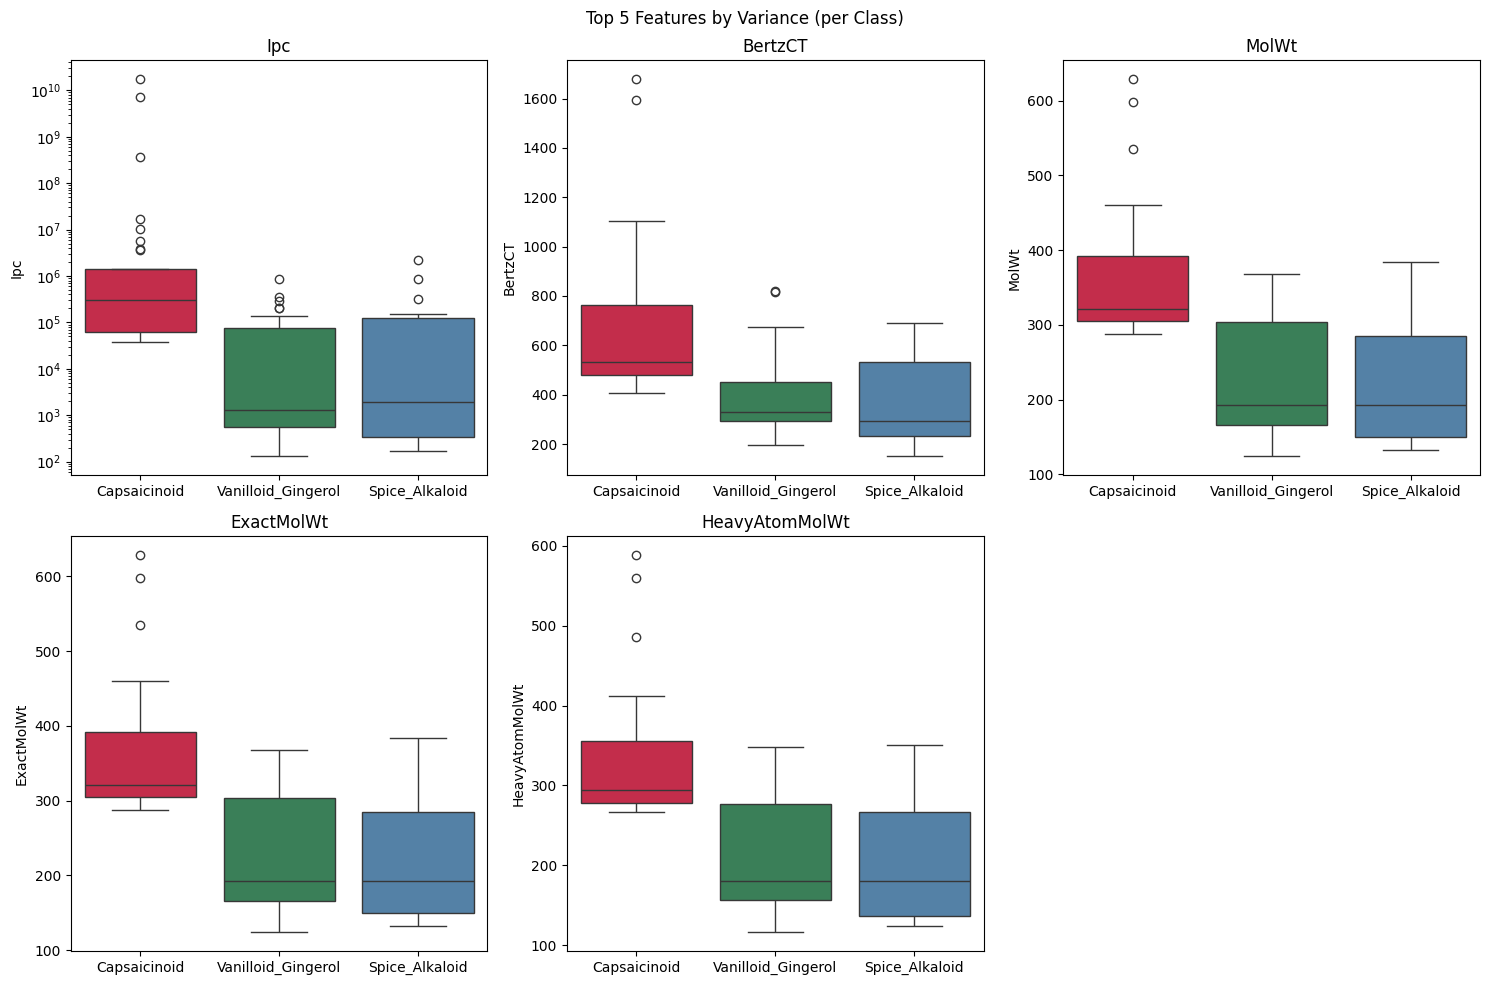

In [240]:
top_5_features = feature_data.var().nlargest(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for idx, feat in enumerate(top_5_features):
    sns.boxplot(data=molecule_df, x="class_name", y=feat,
                hue="class_name", palette=colors, legend=False, ax=axes[idx])
    axes[idx].set_title(feat)
    axes[idx].set_xlabel("")
    if molecule_df[feat].max() / (molecule_df[feat].min() + 1) > 1000:
        axes[idx].set_yscale("log")

axes[-1].set_visible(False)
plt.suptitle("Top 5 Features by Variance (per Class)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "top5_boxplots.png"), bbox_inches="tight")
plt.show()

Among the top 5 high-variance features, Ipc shows the clearest class separation. In contrast, BertzCT, MolWt, ExactMolWt, and HeavyAtomMolWt show substantial overlap across classes, so they appear less informative as standalone features. In addition, MolWt, ExactMolWt, and HeavyAtomMolWt follow very similar patterns, which suggests strong redundancy among them.

## 2.6 The p > n Problem

This dataset has **99 samples and 165 features**, so the number of features is larger than the number of observations (**p > n**). This can be a problem because the model may fit the training set too closely and fail to generalize well to new data.

### Why use embedded feature selection?

Instead of manually dropping features based on variance or correlation, I used a regularized classifier to select features in a more data-driven way. Here, I used Elastic Net regularization, which combines L1 and L2 penalties.

This has a few advantages:
- it uses the class labels while selecting features
- it can reduce the feature space to a much smaller and more practical subset
- it is more flexible than pure L1 because the balance between sparsity and stability can be adjusted

In this notebook, the goal is not to keep as many original features as possible, but to find a compact feature set that is more reasonable for a small-sample, high-dimensional dataset.

## 2.7 Train/Test Split

Split **before** any preprocessing to prevent data leakage.
All filtering, scaling, and PCA will be fit on train only.

In [241]:
feature_cols = molecule_df.columns[3:]
X = molecule_df[feature_cols].copy()
y = molecule_df["class_label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"Feature / training sample ratio: {X_train.shape[1] / X_train.shape[0]:.1f}")

Training set: 69 samples, 165 features
Test set: 30 samples, 165 features
Feature / training sample ratio: 2.4


## 2.8 Feature Reduction — Elastic Net Selection

In this step, I used a regularized logistic regression model with **Elastic Net** to reduce the feature space. Elastic Net combines **L1** and **L2** regularization, so it can shrink coefficients while also setting some of them to zero.

The two main hyperparameters are:
- `L1_ratio`: controls the balance between L1 and L2
- `C`: controls the overall regularization strength

A smaller `C` means stronger regularization, so fewer features are usually kept.

Here, I tested several combinations of `L1_ratio` and `C` to see how many features remain under each setting, and then chose a more practical configuration for this dataset.

In [242]:
import warnings
warnings.filterwarnings('ignore')

# Scale features for Elastic Net selection
scaler_en = StandardScaler()
X_train_en = scaler_en.fit_transform(X_train)

# Grid of hyperparameters
L1_ratios = [0.3, 0.5, 0.7, 0.9]
reg_strengths = [0.01, 0.05, 0.1, 0.5, 1.0]

grid_results = []
for ratio in L1_ratios:
    for strength in reg_strengths:
        model = LogisticRegression(
            penalty="elasticnet",
            l1_ratio=ratio,
            C=strength,
            solver="saga",
            max_iter=20000,
            random_state=42
        )
        model.fit(X_train_en, y_train)
        n_selected = (np.abs(model.coef_).max(axis=0) > 0).sum()
        grid_results.append({
            'L1_ratio': ratio,
            'C': strength,
            'n_features': n_selected
        })

grid_df = pd.DataFrame(grid_results)
grid_pivot = grid_df.pivot(index='L1_ratio', columns='C', values='n_features')

print("Elastic Net Feature Selection Grid")
print("(Number of selected features)\n")
print(grid_pivot.astype(int))


Elastic Net Feature Selection Grid
(Number of selected features)

C         0.01  0.05  0.10  0.50  1.00
L1_ratio                              
0.3          0    50    65    83    92
0.5          0    35    42    68    71
0.7          0    22    30    51    62
0.9          0    10    20    36    44


### Selecting the Main Configuration

From the grid above, we choose hyperparameters that yield a compact yet informative subset.
With **C=0.1, L1_ratio=0.7**, the model selects 30 features: a significant reduction from 165
while retaining enough signal for class discrimination. This balances L1 sparsity and L2 stability.

In [243]:
reg_strength = 0.1
L1_ratio = 0.7

elastic_net = LogisticRegression(
    penalty="elasticnet",
    l1_ratio=L1_ratio,
    C=reg_strength,
    solver="saga",
    max_iter=20000,
    random_state=42
)
elastic_net.fit(X_train_en, y_train)

max_coefs = np.abs(elastic_net.coef_).max(axis=0)
selected_features = X_train.columns[max_coefs > 0].tolist()

print(f"Configuration: C={reg_strength}, L1_ratio={L1_ratio}")
print(f"Selected features: {len(selected_features)} / {X_train.shape[1]}")
print(f"\nAll {len(selected_features)} selected features by |coefficient|:")
feature_importance = pd.Series(max_coefs, index=X_train.columns).sort_values(ascending=False)
print(feature_importance[feature_importance > 0].to_string())


Configuration: C=0.1, L1_ratio=0.7
Selected features: 30 / 165

All 30 selected features by |coefficient|:
fr_NH1                    0.574922
PEOE_VSA9                 0.202791
VSA_EState3               0.186777
fr_phenol_noOrthoHbond    0.172253
fr_Ar_OH                  0.172253
fr_phenol                 0.172253
PEOE_VSA8                 0.172026
fr_ketone                 0.149659
fr_methoxy                0.141753
BCUT2D_LOGPLOW            0.137649
VSA_EState9               0.137579
Chi2v                     0.129251
PEOE_VSA11                0.117950
Chi0v                     0.102266
SMR_VSA3                  0.095833
Chi2n                     0.078322
MolMR                     0.076678
NumHDonors                0.064666
Chi1v                     0.057475
Chi0n                     0.053957
MinAbsEStateIndex         0.046726
EState_VSA3               0.046063
VSA_EState8               0.043390
MolWt                     0.030120
ExactMolWt                0.029042
LabuteASA         

## 2.9 Scaling

StandardScaler applied to the selected features, fit on train only.

In [244]:
# Extract selected features from train and test
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# Scale selected features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

print(f"Selected features: {X_train_scaled.shape[1]}")
print(f"Train scaled: mean={X_train_scaled.mean():.3f}, std={X_train_scaled.std():.4f}")


Selected features: 30
Train scaled: mean=0.000, std=1.0000


## 2.10 PCA Visualization

The selected 30 features are already compact and interpretable. PCA is not needed for the pipeline,
but we can still use 2D PCA as a visualization tool to explore class structure.

Note: PCA maximizes variance, not class separability, so overlaps are expected and normal.

In [245]:
# 2D PCA for visualization only
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_scaled)
X_test_2d = pca_2d.transform(X_test_scaled)

print(f"PCA 2D explained variance: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")
print(f"PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}%")


PCA 2D explained variance: 73.5%
PC1: 53.1%
PC2: 20.3%


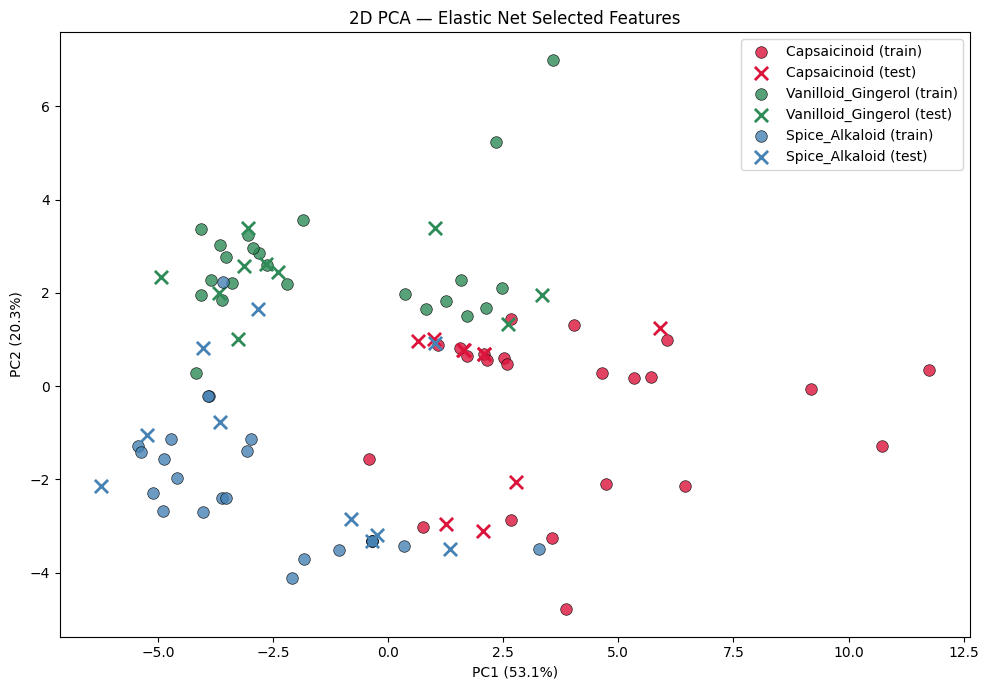

In [246]:
class_names = ["Capsaicinoid", "Vanilloid_Gingerol", "Spice_Alkaloid"]
class_colors = ["crimson", "seagreen", "steelblue"]

fig, ax = plt.subplots(figsize=(10, 7))

for cls, name, color in zip([0, 1, 2], class_names, class_colors):
    ax.scatter(
        X_train_2d[y_train == cls, 0],
        X_train_2d[y_train == cls, 1],
        c=color, alpha=0.8, s=70, edgecolors="k", linewidth=0.5,
        label=f"{name} (train)"
    )
    ax.scatter(
        X_test_2d[y_test == cls, 0],
        X_test_2d[y_test == cls, 1],
        c=color, marker="x", s=90, linewidths=2,
        label=f"{name} (test)"
    )

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("2D PCA — Elastic Net Selected Features")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pca_2d_scatter.png"), bbox_inches="tight")
plt.show()

The 2D scatter shows how the classes project onto the first two principal components.
PCA preserves variance but not class separability, so some overlap is normal and expected.
Test points (X) falling near their respective train clusters indicate good generalization of the feature space.

## 2.11 Save Artifacts

In [247]:
joblib.dump({
    "X_train_scaled": X_train_scaled,
    "X_test_scaled": X_test_scaled,
    "y_train": y_train,
    "y_test": y_test,
    "selected_features": selected_features,
    "L1_ratio": L1_ratio,
    "C": reg_strength
}, os.path.join(DATA_DIR, "model_input_elasticnet.joblib"))

print("Saved: model_input_elasticnet.joblib")


Saved: model_input_elasticnet.joblib


## 2.12 Next Steps

**Upcoming:**
- A deep learning classifier built in PyTorch as a practice exercise
- Possible additional data analysis depending on modeling results

---

**Reflection**

In the first version of this notebook, I ran PCA on all 165 features, chose the number of components from the explained variance, and used those components for later modeling. The code worked and the plots looked reasonable, but the main issue was still there: this dataset has 99 samples and 165 features.

Since this is a p > n setting, overfitting is a real concern. A model can fit the training data too closely, especially when many features are redundant or not very informative.

PCA helps reduce dimensionality, but it does not use the class labels. It keeps directions with large variance, not necessarily directions that are most useful for classification.

Because of that, I moved to Elastic Net regularization. Elastic Net combines L1 and L2 penalties, so it can both shrink coefficients and remove some features. This makes it more suitable for reducing the feature space in a small-sample, high-dimensional dataset.

So instead of relying only on PCA, I first used Elastic Net logistic regression to select a smaller set of useful features, and then applied scaling to that reduced feature set. This gives a more practical input for later modeling and helps reduce the risk of overfitting.